# FINAL PROJECT: Computational Cognitive Science

Participants:
- Ashhad Raza Quadri
- Saliq Neyaz
- Maria Alejandra Pabon Galindo

In [1]:
# Imports
import pandas as pd
import glob
from scipy.io import loadmat
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt



## 1. Data

In [2]:
DATASET = "PD_data"

#Check format of the data
files = sorted(glob.glob(DATASET + "/*.mat")) 
print(len(files), "files")

m = loadmat(files[0])
for k, v in m.items():
    if k.startswith("__"):
        continue
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))
labels = [str(x).strip() for x in m['data_labels'].ravel()]
print(labels)

49 files
data_labels <class 'numpy.ndarray'> (1, 8) object
data_test <class 'numpy.ndarray'> (200, 8) float64
data_train <class 'numpy.ndarray'> (200, 8) float64
["['certOutcome']", "['uncOutcome']", "['outcome prob.']", "['action (1=certain, 2=uncertain, 0=missing)']", "['p_cert']", "['condition (1=reward,2=loss)']", "['RT']", "['odds']"]


In [3]:
COLS = ["r_cert", "r_unc", "prob", "choice", "p_cert", "condition", "rt", "odds"]
EXPECTED = ['certOutcome', 'uncOutcome', 'outcome prob.',
            'action (1=certain, 2=uncertain, 0=missing)', 'p_cert',
            'condition (1=reward,2=loss)', 'RT', 'odds']
            

### 1.1 Data loading

In [4]:
RT_LO = 0.25    # secs
FAST_THR     = 0.40           # threshold for marking “rapid response”
FAST_MAX     = 0.10           # >10% of rapid tests = participant flagged
MIN_TRIALS   = 80             # minimum number of valid trials per run

EXCLUDE_FLAGGED = False

plt.rcParams.update({"figure.dpi": 110, "font.size": 9,
                     "axes.spines.top": False, "axes.spines.right": False})



def read_labels(m):
    lab = np.atleast_1d(np.squeeze(m["data_labels"]))
    return [str(np.squeeze(x)).strip() for x in lab]

def load_data(data_dir):
    files = sorted(Path(data_dir).glob("*.mat"))
    if not files:
        raise FileNotFoundError(f"No .mat files in {data_dir}")
    frames = []
    for f in files:
        m = loadmat(f, squeeze_me=True)
        
        if read_labels(m) != EXPECTED:
            raise ValueError(f"{f.name}: unexpected labels -> {read_labels(m)}")

        for run, key in [("A", "data_train"), ("B", "data_test")]:
            arr = np.atleast_2d(np.asarray(m[key], dtype=float))
            if arr.shape[1] != len(COLS):
                raise ValueError(f"{f.name}/{key}: {arr.shape[1]} cols, expected {len(COLS)}")
            d = pd.DataFrame(arr, columns=COLS)
            d.insert(0, "trial", np.arange(1, len(d) + 1))
            d.insert(0, "run", run)
            d.insert(0, "participant_id", f.stem)
            frames.append(d)
    return pd.concat(frames, ignore_index=True)

df = load_data(DATASET) 
print(df.participant_id.nunique(), "participants,", len(df), "trials")
print(df.groupby("run").size().to_dict())
df.head()

49 participants, 19600 trials
{'A': 9800, 'B': 9800}


,participant_id,run,trial,r_cert,r_unc,prob,choice,p_cert,condition,rt,odds
0,2rrjzhgj9,A,1,-1.0,-1.30,25.0,2.0,NaN,2.0,2351.9,3.000000
1,2rrjzhgj9,A,2,-20.0,-200.00,25.0,1.0,NaN,2.0,2610.8,3.000000
2,2rrjzhgj9,A,3,-50.0,-1550.00,25.0,1.0,NaN,2.0,2924.4,3.000000
3,2rrjzhgj9,A,4,-10.0,-21.11,90.0,1.0,NaN,2.0,2452.4,0.111111
4,2rrjzhgj9,A,5,-1.0,-1.01,90.0,2.0,NaN,2.0,2789.7,0.111111


### 1.2 Data cleaning

1. Drop trials with a missing choice (`choice == 0`) -- these are timeouts, with `RT == NaN`.
2. Drop trials with `RT < 250ms` (a fixed, global floor, not computed per participant) to exclude implausibly fast anticipatory/guess responses. The raw data is already hard-bounded at exactly [200, 9996] ms (0% of trials outside that range), so this only removes trials in the 200-250ms band.
3. Separately (see the per-participant diagnostic below), flag -- but do not drop -- participants whose proportion of fast responses or extreme choice rate looks atypical; `EXCLUDE_FLAGGED` is currently `False`, so no participant is excluded on this basis yet.


In [5]:
def clean(df, rt_lo=RT_LO, verbose=True):
    d, n0 = df.copy(), len(df)

    # Exclude non-responses (these are timeouts; their RT is NaN)
    d = d[d.choice.isin([1, 2])]
    n1 = len(d)

    # 2) units: ms -> s
    d["rt"] = d.rt / 1000.0

    # 3) RT limits
    fasts = int((d.rt < rt_lo).sum())
    d = d[(d.rt >= rt_lo)]
    n2 = len(d)

    # 4) derived columns
    d["p"]     = d.prob / 100.0                          # percentage -> proportion
    d["theta"] = (1 - d.p) / d.p                         # probabilities against
    d["y"]     = (d.choice == 2).astype(float)           # 1 = chose the uncertain option
    d["scale"] = (d.r_cert.abs() + d.r_unc.abs()) / 2    # numerical normalization of ΔV
    d["ratio"] = d.r_unc.abs() / d.r_cert.abs()          # ratio of magnitudes

    # verification: the odds column in the file should match our formula
    if not np.allclose(d.odds, d.theta, rtol=1e-6):
        print("WARN: column 'odds' does not match (1-p)/p; using calculated theta")
    assert (d[d.condition == 1][["r_cert", "r_unc"]] > 0).all().all(), "non-positive earnings"
    assert (d[d.condition == 2][["r_cert", "r_unc"]] < 0).all().all(), "non-negative losses"

    if verbose:
        print(f"no-response : {n0-n1:5d}  ({(n0-n1)/n0:.3%})")
        print(f"RT < {rt_lo}s   : {fasts:5d}  ({fasts/n1:.3%})")
        print(f"left       : {n2} trials, {d.participant_id.nunique()} participants")
        print("\nRT after cleaning (s):",
              d.rt.describe([.01, .5, .99]).round(2).to_dict())
        print("ratio |r_unc|/|r_cert|:", d.ratio.describe([.05, .5, .95]).round(2).to_dict())

    return d.reset_index(drop=True)

data = clean(df)

no-response :    68  (0.347%)
RT < 0.25s   :   105  (0.538%)
left       : 19427 trials, 49 participants

RT after cleaning (s): {'count': 19427.0, 'mean': 2.25, 'std': 1.36, 'min': 0.25, '1%': 0.32, '50%': 1.95, '99%': 6.98, 'max': 10.0}
ratio |r_unc|/|r_cert|: {'count': 19427.0, 'mean': 284.84, 'std': 6883.3, 'min': 0.99, '5%': 1.0, '50%': 2.23, '95%': 91.0, 'max': 626347.84}


### 1.3 Data diagnosis

In [6]:
# ---------- Per-participant diagnostic ----------
# One row per participant. Documents the sample and is used in Step 7
# to check whether the atypical/outlier participants are the ones that fit worst.

r = df[df.choice.isin([1, 2])].copy()
r["rt_s"] = r.rt / 1000
r["y"]    = (r.choice == 2).astype(float)

QC = pd.DataFrame({
    "prop_fast":   r.groupby("participant_id").rt_s.apply(lambda x: (x < FAST_THR).mean()),
    "rt_median":   r.groupby("participant_id").rt_s.median(),
    "p_uncertain": r.groupby("participant_id").y.mean(),
})
QC["extreme"] = (QC.p_uncertain < .05) | (QC.p_uncertain > .95)
QC["fast"]    = QC.prop_fast > FAST_MAX

print(f"extreme choice (>95% one option): {QC.extreme.sum()} participants")
print(f"fast RTs (>{FAST_MAX:.0%} below {FAST_THR}s): {QC.fast.sum()} participants")
print(QC[QC.extreme | QC.fast].round(3))


extreme choice (>95% one option): 0 participants
fast RTs (>10% below 0.4s): 4 participants
                prop_fast  rt_median  p_uncertain  extreme  fast
participant_id                                                  
bh348lli7           0.569      0.379        0.321    False  True
orxx7nl6z           0.218      0.656        0.382    False  True
ru26ufirj           0.119      2.054        0.424    False  True
s4xqtibhr           0.454      0.443        0.480    False  True


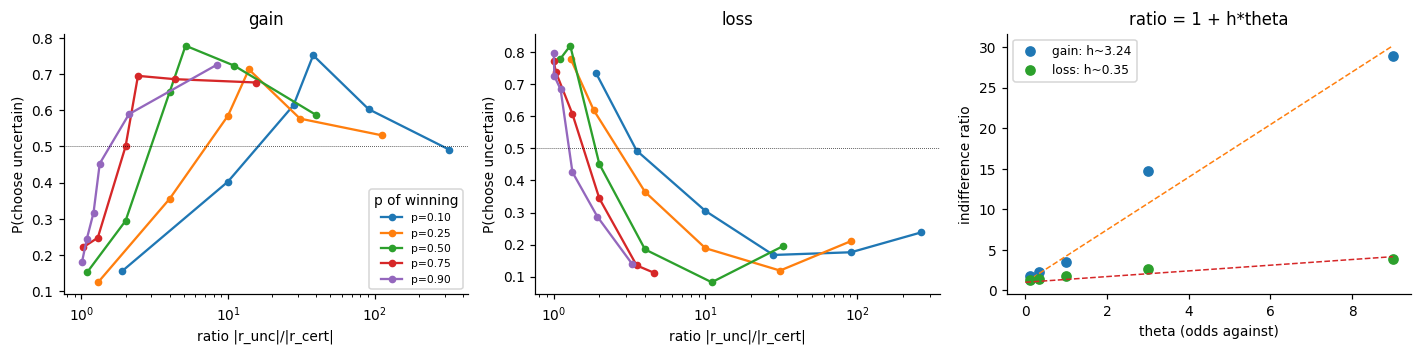

   cond     p  theta  ratio_indiff  slope
0     1  0.10  9.000        28.889  0.264
1     1  0.25  3.000        14.780  0.358
2     1  0.50  1.000         3.513  0.869
3     1  0.75  0.333         2.212  1.249
4     1  0.90  0.111         1.832  1.954
5     2  0.10  9.000         3.882 -0.837
6     2  0.25  3.000         2.668 -1.329
7     2  0.50  1.000         1.831 -2.493
8     2  0.75  0.333         1.462 -3.182
9     2  0.90  0.111         1.301 -4.312

empirical h: {1: 3.241, 2: 0.351}


In [7]:
from scipy.optimize import curve_fit

fig, ax = plt.subplots(1, 3, figsize=(13, 3.3))

# --- Panels 1-2: choice vs. magnitude ratio, by level of p ---
for i, (c, lab) in enumerate([(1, "gain"), (2, "loss")]):
    d = data[data.condition == c]
    for p_val in sorted(d.p.unique()):
        dp = d[d.p == p_val]
        b = pd.qcut(np.log(dp.ratio), 6, duplicates="drop")
        g = dp.groupby(b, observed=True).agg(x=("ratio", "median"), y=("y", "mean"))
        ax[i].plot(g.x, g.y, "o-", ms=4, label=f"p={p_val:.2f}")
    ax[i].set_xscale("log")
    ax[i].axhline(.5, color="k", lw=.5, ls=":")
    ax[i].set(xlabel="ratio |r_unc|/|r_cert|", ylabel="P(choose uncertain)", title=lab)
ax[0].legend(fontsize=7, title="p of winning")

# --- Panel 3: model-free empirical h ---
# At indifference V_unc = V_cert  ->  ratio = 1 + h*theta  (line with slope h)
rows = []
for c in [1, 2]:
    sign = 1 if c == 1 else -1          # losses: negative logistic slope
    for p_val in sorted(data.p.unique()):
        d = data[(data.condition == c) & (data.p == p_val)]
        if d.y.std() == 0:
            continue
        try:
            a, b_ = curve_fit(lambda x, a, b: 1/(1+np.exp(-(a+b*x))),
                              np.log(d.ratio.values), d.y.values,
                              p0=[0, sign], maxfev=20000)[0]
            if np.sign(b_) == sign and abs(b_) > 1e-3:
                rows.append(dict(cond=c, p=p_val, theta=(1-p_val)/p_val,
                                  ratio_indiff=np.exp(-a/b_), slope=b_))
        except Exception:
            pass
IND = pd.DataFrame(rows)

H_EMP = {}
for c, lab in [(1, "gain"), (2, "loss")]:
    d = IND[IND.cond == c]
    if len(d) < 2:
        print(f"WARNING: only {len(d)} indifference points for {lab}")
        continue
    h = float(np.sum(d.theta * (d.ratio_indiff - 1)) / np.sum(d.theta**2))
    H_EMP[c] = h
    ax[2].plot(d.theta, d.ratio_indiff, "o", label=f"{lab}: h~{h:.2f}")
    tt = np.linspace(0, d.theta.max(), 50)
    ax[2].plot(tt, 1 + h*tt, "--", lw=1)
ax[2].set(xlabel="theta (odds against)", ylabel="indifference ratio",
          title="ratio = 1 + h*theta")
ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()
print(IND.round(3))
print("\nempirical h:", {k: round(v, 3) for k, v in H_EMP.items()})


In [8]:
# ---------- Preprocessing summary (for the methods section) ----------
summary = {
    "participants":           data.participant_id.nunique(),
    "raw_trials":              len(df),
    "final_trials":            len(data),
    "excl_no_response":        int((~df.choice.isin([1, 2])).sum()),
    "excl_fast_rt":            len(df) - int((~df.choice.isin([1, 2])).sum()) - len(data),
    "h_emp_gain":              round(H_EMP.get(1, np.nan), 3),
    "h_emp_loss":              round(H_EMP.get(2, np.nan), 3),
    "flagged_fast_rt":         int(QC.fast.sum()),
    "flagged_extreme_choice":  int(QC.extreme.sum()),
}
print(pd.Series(summary))

print("\ntrials per participant x run x condition cell:")
print(data.groupby(["run", "condition"]).size().unstack())


participants                 49.000
raw_trials                19600.000
final_trials              19427.000
excl_no_response             68.000
excl_fast_rt                105.000
h_emp_gain                    3.241
h_emp_loss                    0.351
flagged_fast_rt               4.000
flagged_extreme_choice        0.000
dtype: float64

trials per participant x run x condition cell:
condition   1.0   2.0
run                  
A          4877  4850
B          4851  4849


## 2. Valuation model & choice rule

**Valuation model — Rachlin hyperboloid-in-odds probability discounting** (Rachlin,
Raineri & Cross, 1991). The certain option carries no risk and needs no discounting:
$$V_{cert} = r_{cert}$$
The uncertain option is discounted by the odds against its probabilistic outcome,
$\Theta = (1-p)/p$:
$$V_{unc}(h) = \frac{r_{unc}}{1 + h\,\Theta}, \qquad h \ge 0$$

The hyperbolic form is supported by our own data, not assumed: at indifference the equation rearranges to $r_{unc}/r_{cert} = 1 + h\theta$, so indifference ratios should be **linear in θ**. The non-parametric estimates in Section 1 fall close to that line (h ≈ 3.24 gains, h ≈ 0.35 losses) and serve as a validation target for the fitted parameters.

- Two rates per participant: (h_gain, h_loss). The design is fully crossed (100 trials per
condition per run), and the two model-free rates differ by nearly an order of magnitude, so a
single rate would fit neither domain.
- Sign handling: Loss magnitudes are stored as negative (verified with the data). No sign correction is applied, the same equation then produces both risk attitudes: for gains V_unc shrinks toward 0 and so is *worse* than the sure gain (risk aversion); for losses it shrinks toward 0 and so is *better* than the sure loss (risk seeking). The reflection effect emerges with no extra parameter.
- Scaling: $\Delta V = (V_{unc} − V_{cert}) / [(|r_{cert}| + |r_{unc}|)/2]$. Purely numerical, magnitudes span five orders of magnitude, so without normalisation no single β could serve both small and large trials. The cost is that absolute magnitude effects cannot be expressed through this predictor.


**Choice rule (logistic on $\Delta V$):**

$$P(\text{uncertain}) = \sigma(\beta\,\Delta V + \beta_0)$$

$\beta$ is choice sensitivity (large $\beta$ = choices follow value deterministically); $\beta_0$ absorbs a value-independent bias. **Consistent with Section 1:** the model-free choice curves there (binned by magnitude ratio, separately by θ) already show the qualitative pattern this valuation model predicts — monotonic in the ratio, with the reward and loss conditions moving in opposite directions around the point of indifference. A direct $\Delta V$-binned check (using fitted h, β) is a natural addition once model fitting is available later in the notebook.

**Parameterisation and likelihood**
Four parameters per participant, fitted unconstrained: `log_h_gain`, `log_h_loss`, `log_beta` (log scale keeps rates positive without bounded optimisation and improves conditioning) and `beta0` (unconstrained; bias may point either way).

$$\mathcal{L}_{choice} = \sum_t \big[ y_t \log P_t + (1-y_t)\log(1-P_t) \big]$$

This term is identical in every model, including the choice-only baseline. The RT models add a second term; the baseline omits it. The two likelihoods describe different data and are not directly comparable.

**Limitations**
* One β across conditions, though choices tracked value more sharply for losses — worth checking via calibration once model fitting is added.
* Normalising ΔV removes magnitude effects.
* h and β assumed constant within a run (no learning, fatigue, or drift).


**The RT distribution (held fixed): Shifted log-normal**

The brief requires that the noise distribution be identical across all RT models. If it varied, the comparison would partly measure distributional shape rather than isolating the value→RT mapping, which is the object of interest.

$$RT = \tau + \exp(\mu + \sigma\varepsilon), \qquad \varepsilon \sim \mathcal{N}(0,1)$$

**Log-density.** For rt > τ:

$$\log f(rt) = -\log(rt-\tau) - \log\sigma - \tfrac{1}{2}\log 2\pi
- \tfrac{1}{2}\left[\frac{\log(rt-\tau) - \mu}{\sigma}\right]^2$$

### Parameters

| Fitted | Recovered as | Role |
|---|---|---|
| `a`, `b` | — | Define μ; this is the only part that differs across models. |
| `log_sigma` | σ = exp(·) | RT variability on the log scale; must be positive. |
| `tau_raw` | τ = logistic(τ_raw)·0.99·min(RT) | Non-decision time. |


### 2.1 The RT models

All models share the valuation model, the choice rule, and the shifted log-normal above. They
differ only in how ΔV enters the location parameter μ.

### M1 — Linear conflict

$$\mu = a - b\,|\Delta V|$$

**Hypothesis.** Response time is driven by the *distance between the options in value space*.
The further apart they are, the faster the comparison resolves; when ΔV ≈ 0 the comparison
stalls and the response is delayed.

**Motivation.** In an evidence-accumulation (diffusion) process the drift rate is proportional
to the value difference, and mean decision time decreases approximately linearly in drift for
small drift rates. M1 is that first-order approximation.


### M2 — Decision uncertainty

$$\mu = a - b\,\big|2P(\text{uncertain}) - 1\big|$$

**Hypothesis.** What slows responding is not the objective value distance but *subjective
indecision*. The predictor measures how far the choice probability sits from 50/50: it is 0
under complete indecision and 1 under complete certainty.

**How it differs psychologically from M1.** The difference is **saturation**. Under M1,
each additional unit of ΔV always speeds responding by the same amount. Under M2, once the
participant is already nearly certain (P ≈ 0.95), further value advantage buys no additional
speed — the predictor has reached ceiling. M1 says RT tracks value; M2 says RT tracks
confidence.


### Summary of the distinction

| | Predictor | What slows the participant | Behaviour at large \|ΔV\| |
|---|---|---|---|
| **M1** | \|ΔV\| | Value distance | Keeps speeding up linearly |
| **M2** | \|2P−1\| | Subjective indecision | Saturates once the choice is clear |


In [ ]:
from scipy.special import expit

# ==================== valuation & choice (FIXED) ====================
CHOICE_PARS = ["log_h_gain", "log_h_loss", "log_beta", "beta0"]

def compute_dv(pars, d):
    """Normalized value difference. Magnitudes are already signed: no sign correction applied."""
    h     = np.where(d.condition.values == 2,
                     np.exp(pars["log_h_loss"]), np.exp(pars["log_h_gain"]))
    V_unc = d.r_unc.values / (1.0 + h * d.theta.values)
    return (V_unc - d.r_cert.values) / d.scale.values

def choice_prob(pars, dv):
    z = np.clip(np.exp(pars["log_beta"]) * dv + pars["beta0"], -500, 500)
    return np.clip(expit(z), 1e-12, 1 - 1e-12)

def ll_choice(pars, d, dv=None, pu=None):
    """Choice log-likelihood, per trial (Bernoulli)."""
    dv = compute_dv(pars, d) if dv is None else dv
    pu = choice_prob(pars, dv) if pu is None else pu
    y  = d.y.values
    return y * np.log(pu) + (1 - y) * np.log(1 - pu)

# ==================== RT distribution (FIXED) ====================
RT_PARS  = ["a", "b", "log_sigma", "tau_raw"]
LL_FLOOR = -20.0     # finite floor for rt <= tau

def get_tau(pars, rt_min):
    """0 < tau < min(RT), guaranteed by the sigmoid transform."""
    return expit(pars["tau_raw"]) * 0.99 * rt_min

def ll_rt(pars, model, d, dv, pu, rt_min, return_viol=False):
    """Shifted log-normal, IDENTICAL across all models: only mu changes."""
    tau   = get_tau(pars, rt_min)
    sigma = np.exp(pars["log_sigma"])
    mu    = rt_location(pars, model, dv, pu)
    resid = d.rt.values - tau
    ok    = resid > 1e-6
    rr    = np.where(ok, resid, 1.0)
    z     = (np.log(rr) - mu) / sigma
    ll    = -np.log(rr) - np.log(sigma) - 0.5*np.log(2*np.pi) - 0.5*z**2
    out   = np.where(ok, ll, LL_FLOOR)
    return (out, int((~ok).sum())) if return_viol else out

# ==================== RT models ====================
RT_MODELS = ["M1_abs", "M2_unc"]

def rt_location(pars, model, dv, pu):
    a, b = pars["a"], pars["b"]
    if model == "M1_abs":
        return a - b * np.abs(dv)              # value distance
    if model == "M2_unc":
        return a - b * np.abs(2 * pu - 1)      # decision uncertainty
    raise ValueError(f"unknown model: {model}")

# ==================== joint likelihood ====================
def log_lik(pars, d, model=None, rt_min=None, use_rt=True):
    """model=None or use_rt=False -> choice-only baseline."""
    dv  = compute_dv(pars, d)
    pu  = choice_prob(pars, dv)
    llc = ll_choice(pars, d, dv, pu)
    if not use_rt or model is None:
        return dict(total=llc.sum(), choice=llc.sum(), rt=np.nan)
    llr = ll_rt(pars, model, d, dv, pu, rt_min)
    return dict(total=llc.sum() + llr.sum(), choice=llc.sum(), rt=llr.sum())

def param_names(model, use_rt=True):
    return CHOICE_PARS + (RT_PARS if (use_rt and model) else [])
